Problem statement

Your objective is to:
Build a machine learning solution to

*   predict the market value of a football player using the given features.
*   Additionally, you are required to evaluate the impact of dimensionality reduction (PCA) and hyperparameter tuning on model performance.




Import libraries


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

Load Dataset

In [9]:
df = pd.read_csv("/content/Player stats.csv", encoding='latin1')

Basic check

In [11]:
df

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,Mohamed Salah,Egypt,175,71,31,Liverpool,86,88,NaN,41,...,84,69,86,83,11,14,14,9,14,$99.500.000
5678,Sadio Mané,Senegal,174,69,31,FC Bayern München,86,88,NaN,38,...,77,64,75,75,7,10,10,15,14,$101.000.000
5679,Neymar Jr,Brazil,175,68,31,Paris SG,94,95,NaN,29,...,88,87,91,86,15,9,9,15,11,$99.500.000
5680,Cristiano Ronaldo,Portugal,187,83,38,Al Nassr,87,81,NaN,24,...,79,75,90,85,14,7,11,15,11,$31.000.000


In [10]:
df.shape

(5682, 41)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5682 non-null   object 
 1   country         5682 non-null   object 
 2   height          5682 non-null   int64  
 3   weight          5682 non-null   int64  
 4   age             5682 non-null   int64  
 5   club            5682 non-null   object 
 6   ball_control    5682 non-null   int64  
 7   dribbling       5682 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5682 non-null   int64  
 10  stand_tackle    5682 non-null   int64  
 11  aggression      5682 non-null   int64  
 12  reactions       5682 non-null   int64  
 13  att_position    5682 non-null   int64  
 14  interceptions   5682 non-null   int64  
 15  vision          5682 non-null   int64  
 16  composure       5682 non-null   int64  
 17  crossing        5682 non-null   i

In [13]:
df.describe()

,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,...,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes
count,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,0.0,5682.000000,5682.000000,5682.000000,5682.000000,...,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.00000,5682.000000,5682.000000,5682.000000
mean,181.670539,75.282295,26.316262,58.912179,56.128476,NaN,46.728441,48.820838,56.324006,61.959345,...,47.164203,48.099789,43.299542,48.174938,42.931890,16.187610,16.43805,16.191834,16.071982,16.570222
std,6.829238,6.998971,4.729967,16.567068,18.772075,NaN,20.519430,20.975966,16.846410,8.893309,...,19.463368,18.086672,17.086473,15.781737,17.912619,17.146572,17.63526,16.993154,16.808674,17.942154
min,156.000000,54.000000,17.000000,8.000000,5.000000,NaN,7.000000,7.000000,11.000000,32.000000,...,5.000000,7.000000,4.000000,8.000000,4.000000,2.000000,2.00000,2.000000,2.000000,3.000000
25%,177.000000,70.000000,23.000000,55.000000,51.000000,NaN,27.000000,30.000000,45.000000,56.000000,...,33.000000,36.000000,32.000000,39.000000,30.000000,8.000000,8.00000,8.000000,8.000000,8.000000
50%,182.000000,75.000000,26.000000,63.000000,62.000000,NaN,54.000000,57.000000,60.000000,62.000000,...,51.000000,50.000000,43.000000,49.000000,44.000000,11.000000,11.00000,11.000000,11.000000,11.000000
75%,186.000000,80.000000,30.000000,69.000000,68.000000,NaN,64.000000,66.000000,69.000000,68.000000,...,62.000000,62.000000,56.000000,60.000000,57.000000,14.000000,14.00000,14.000000,14.000000,14.000000
max,204.000000,102.000000,41.000000,94.000000,95.000000,NaN,87.000000,91.000000,96.000000,93.000000,...,91.000000,93.000000,94.000000,92.000000,90.000000,90.000000,90.00000,87.000000,90.000000,89.000000


Data cleaning

In [14]:
# Drop irrelevant columns
df.drop(['player'], axis=1, inplace=True)

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

Encode categorical

In [15]:
le = LabelEncoder()
df['country'] = le.fit_transform(df['country'])
df['club'] = le.fit_transform(df['club'])

Outlier handling

In [17]:
numeric_df = df.select_dtypes(include=np.number)
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

Feature and target split


In [25]:
X = df.drop('value', axis=1)
y = df['value']

# Clean 'value' column (y)
# Remove currency symbols and thousands separators
y_cleaned = y.astype(str).str.replace(r'[$.]', '', regex=True)
# Convert to numeric, coercing errors to NaN
y_cleaned = pd.to_numeric(y_cleaned, errors='coerce')

# Drop rows where 'value' could not be converted to numeric (NaNs introduced by coerce)
# And align X with the cleaned y
initial_rows = len(X)
X = X[y_cleaned.notna()]
y = y_cleaned.dropna()

print(f"Dropped {initial_rows - len(X)} rows due to invalid 'value' conversion.")

Dropped 0 rows due to invalid 'value' conversion.


In [28]:
# Drop columns with all NaN values
X.dropna(axis=1, how='all', inplace=True)

# Drop rows with any NaN values from X and align y
initial_rows_X = len(X)
nan_rows_X = X.isnull().any(axis=1)
X = X[~nan_rows_X]
y = y[~nan_rows_X]

print(f"Dropped {initial_rows_X - len(X)} rows from X (and y) due to NaN values.")

Dropped 0 rows from X (and y) due to NaN values.


In [30]:
# Impute missing values in X
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

In [31]:
# Re-run Scaling after imputation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
# Re-run Train_test_split after scaling
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [33]:
# Re-run Baseline Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Baseline Linear Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

Baseline Linear Regression
RMSE: 4876008.214252915
R2: 0.3448376779981682


Scaling

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Baseline model

In [34]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Baseline Linear Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

Baseline Linear Regression
RMSE: 4876008.214252915
R2: 0.3448376779981682


Avanced model

In [35]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest
RMSE: 2313549.307453171
R2: 0.85250490567463


PCA Implementation

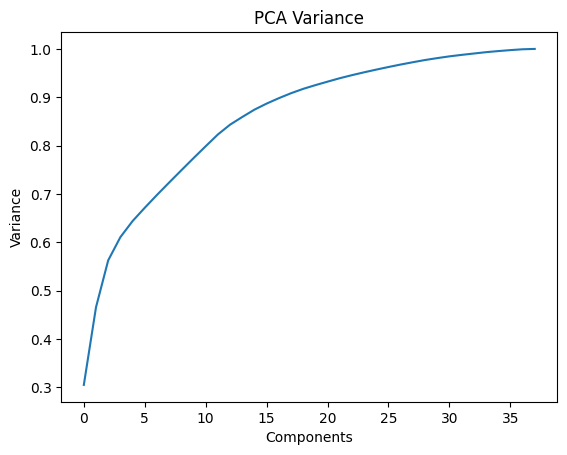

In [36]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Components')
plt.ylabel('Variance')
plt.title('PCA Variance')
plt.show()

In [37]:
# Select components

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

Model with PCA

In [38]:
rf_pca = RandomForestRegressor(random_state=42)
rf_pca.fit(X_train_pca, y_train)

y_pred_pca = rf_pca.predict(X_test_pca)

print("RF with PCA")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_pca)))
print("R2:", r2_score(y_test, y_pred_pca))

RF with PCA
RMSE: 3352732.903782588
R2: 0.6902452537738897


Hyperparameter tuning

In [41]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print("Tuned RF")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned)))
print("R2:", r2_score(y_test, y_pred_tuned))

Tuned RF
RMSE: 2404328.752790141
R2: 0.8407029414733712


Model comparison table

In [42]:
results = pd.DataFrame({
    'Model': ['Linear', 'RF', 'RF + PCA', 'RF Tuned'],
    'R2 Score': [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_pca),
        r2_score(y_test, y_pred_tuned)
    ]
})

print(results)

      Model  R2 Score
0    Linear  0.344838
1        RF  0.852505
2  RF + PCA  0.690245
3  RF Tuned  0.840703
